In [1]:

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np

# Đọc dữ liệu
df = pd.read_csv("online_shoppers_intention.csv")
df.head(10)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
# Thống kê mô tả các biến số
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [5]:
# Kiểm tra số lượng giá trị thiếu ở từng cột
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
# Kiểm tra số dòng trùng lặp
df.duplicated().sum()

np.int64(125)

In [7]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False


In [8]:
df_clean = df.drop_duplicates()

print("Số dòng ban đầu:", df.shape[0])
print("Số dòng sau khi xóa trùng lặp:", df_clean.shape[0])
print("Số dòng đã xóa:", df.shape[0] - df_clean.shape[0])

Số dòng ban đầu: 12330
Số dòng sau khi xóa trùng lặp: 12205
Số dòng đã xóa: 125


In [9]:
# Đếm số lượng từng lớp của Revenue
df_clean['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [10]:
df_clean['Revenue'].value_counts(normalize=True) * 100

Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64

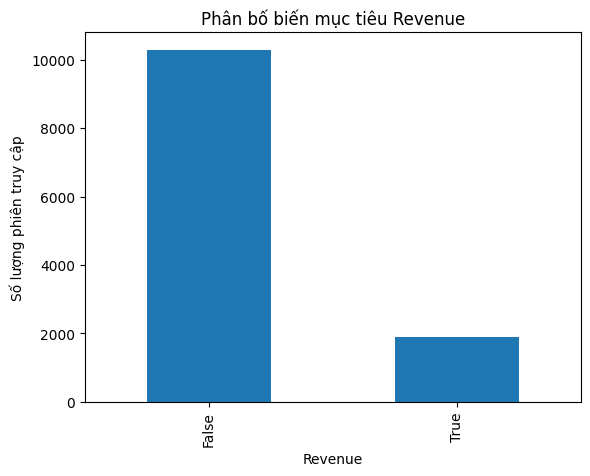

In [11]:
import matplotlib.pyplot as plt

df_clean['Revenue'].value_counts().plot(kind='bar')

plt.title('Phân bố biến mục tiêu Revenue')
plt.xlabel('Revenue')
plt.ylabel('Số lượng phiên truy cập')
plt.show()

In [12]:
categorical_cols = ['Month', 'VisitorType', 'Weekend', 'Revenue']

for col in categorical_cols:
    print("Cột:", col)
    print(df_clean[col].value_counts())
    print("-" * 40)

Cột: Month
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64
----------------------------------------
Cột: VisitorType
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64
----------------------------------------
Cột: Weekend
Weekend
False    9346
True     2859
Name: count, dtype: int64
----------------------------------------
Cột: Revenue
Revenue
False    10297
True      1908
Name: count, dtype: int64
----------------------------------------


MÃ HÓA REVENUE


In [14]:
# Tách biến đầu vào X và biến mục tiêu y
X = df_clean.drop('Revenue', axis=1)
y = df_clean['Revenue']

In [15]:
# Mã hóa biến phân loại bằng One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Chuyển Revenue từ True/False sang 1/0
y_encoded = y.astype(int)

X_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [16]:
print("Kích thước X sau mã hóa:", X_encoded.shape)
print("Kích thước y:", y_encoded.shape)

Kích thước X sau mã hóa: (12205, 26)
Kích thước y: (12205,)


CHIA DỮ LIỆU ĐỂ TRAIN/TEST

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9764, 26)
X_test: (2441, 26)
y_train: (9764,)
y_test: (2441,)


In [18]:
revenue_count = df_clean['Revenue'].value_counts()
revenue_percent = df_clean['Revenue'].value_counts(normalize=True) * 100

revenue_summary = pd.DataFrame({
    'Số lượng': revenue_count,
    'Tỷ lệ (%)': revenue_percent
})

revenue_summary

,Số lượng,Tỷ lệ (%)
Revenue,,
False,10297,84.367063
True,1908,15.632937


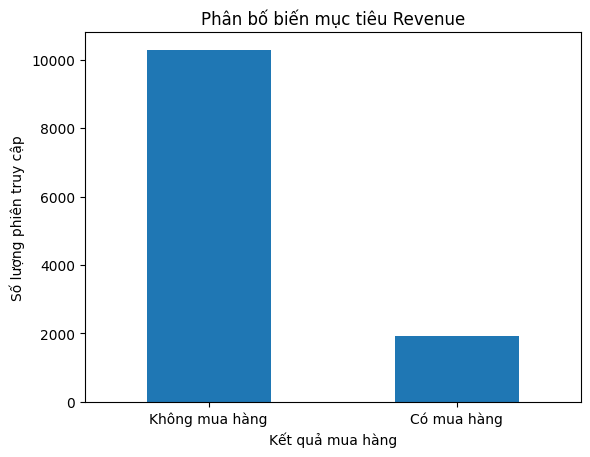

In [22]:
df_clean['Revenue_Label'] = df_clean['Revenue'].map({
    False: 'Không mua hàng',
    True: 'Có mua hàng'
})

revenue_count = df_clean['Revenue_Label'].value_counts()

revenue_count.plot(kind='bar')

plt.title('Phân bố biến mục tiêu Revenue')
plt.xlabel('Kết quả mua hàng')
plt.ylabel('Số lượng phiên truy cập')
plt.xticks(rotation=0)
plt.show()

In [23]:
group_compare = df_clean.groupby('Revenue')[
    [
        'PageValues',
        'BounceRates',
        'ExitRates',
        'ProductRelated',
        'ProductRelated_Duration',
        'Administrative',
        'Administrative_Duration'
    ]
].mean()

group_compare

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration,Administrative,Administrative_Duration
Revenue,,,,,,,
False,1.999985,0.023197,0.045526,29.050403,1082.976881,2.143440,74.635276
True,27.264518,0.005117,0.019555,48.210168,1876.209615,3.393606,119.483244


In [24]:
group_compare.round(3)

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration,Administrative,Administrative_Duration
Revenue,,,,,,,
False,2.000,0.023,0.046,29.05,1082.977,2.143,74.635
True,27.265,0.005,0.020,48.21,1876.210,3.394,119.483


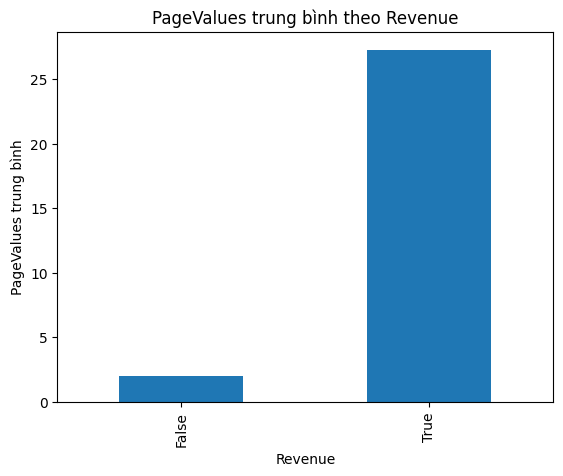

In [25]:
df_clean.groupby('Revenue')['PageValues'].mean().plot(kind='bar')

plt.title('PageValues trung bình theo Revenue')
plt.xlabel('Revenue')
plt.ylabel('PageValues trung bình')
plt.show()

Nhóm mua hàng có Pagevalue cao hơn nhóm không mua hàng rất nhiều

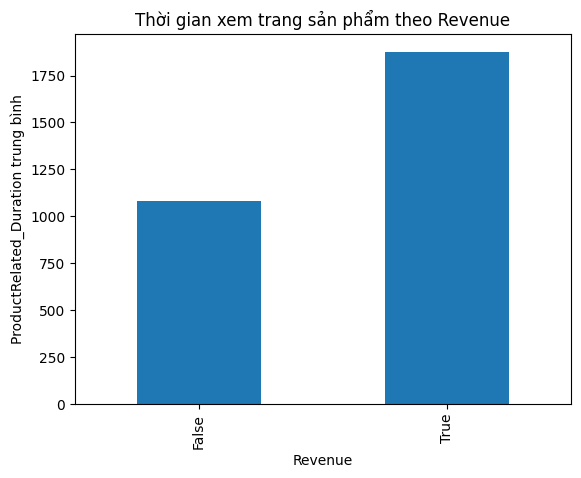

In [26]:
df_clean.groupby('Revenue')['ProductRelated_Duration'].mean().plot(kind='bar')

plt.title('Thời gian xem trang sản phẩm theo Revenue')
plt.xlabel('Revenue')
plt.ylabel('ProductRelated_Duration trung bình')
plt.show()